In [1]:
!nvidia-smi

Mon Mar  9 02:48:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.00                 Driver Version: 577.00         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 30%   50C    P3             45W /  225W |    1426MiB /   8192MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [3]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.63  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
Setup complete  (20 CPUs, 15.7 GB RAM, 768.9/930.7 GB disk)


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\albumentations\core\composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
C:\Users\User\AppData\Local\Temp\ipykernel_7176\981659953.py:67: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5,15), p=0.5),


找到 2168 張訓練圖


增強中: 100%|██████████████████████████████████████████████████████████████████████| 2168/2168 [03:59<00:00,  9.05it/s]


✅ 增強完成！檢查 train_aug_v2/ 資料夾


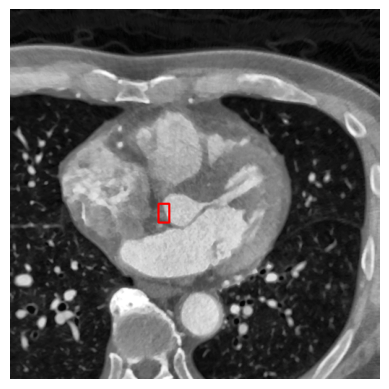

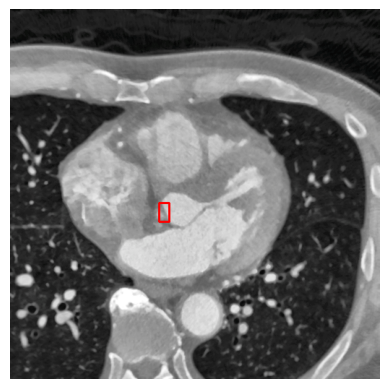

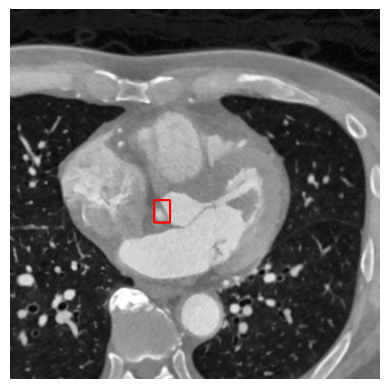

In [4]:
# 主動脈瓣 CT 專用資料增強 Jupyter Notebook
# 針對模糊低對比圖片：CLAHE + 去噪 + 幾何增強

## 0. 安裝套件
!pip install albumentations opencv-python tqdm

## 1. 匯入與路徑設定
import os
import cv2
import glob
import numpy as np
from tqdm import tqdm
import albumentations as A
from PIL import Image
import matplotlib.pyplot as plt

# 改成你的路徑
ROOT = "../datasets"
img_dir = os.path.join(ROOT, "train/images")
lbl_dir = os.path.join(ROOT, "train/labels")

out_img_dir = os.path.join(ROOT, "train_aug_v2/images")
out_lbl_dir = os.path.join(ROOT, "train_aug_v2/labels")
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

IMG_SIZE = 640

## 2. 讀取 YOLO labels（支援浮點 cls）
def read_yolo_labels(lbl_path):
    if not os.path.exists(lbl_path):
        return []
    boxes = []
    with open(lbl_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) != 5: continue
            try:
                cls_float = float(parts[0])
                cls = int(cls_float)  # 0.000 -> 0
                x, y, w, h = map(float, parts[1:])
                if 0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1:
                    boxes.append([cls, x, y, w, h])
            except:
                continue
    return boxes

def write_yolo_labels(lbl_path, boxes):
    with open(lbl_path, "w") as f:
        for cls, x, y, w, h in boxes:
            f.write(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

## 3. CT 主動脈瓣專用增強（針對模糊圖）
bbox_params = A.BboxParams(format="yolo", label_fields=["class_labels"])

# 針對你模糊瓣環圖的 5 種專用增強
augs = {
    # 1. CLAHE + 去噪（針對模糊瓣環）
    "clahe": A.Compose([
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8,8), p=1.0),
        A.RandomGamma(gamma_limit=(80,120), p=0.8),
    ], bbox_params=bbox_params),

    # 2. 對比 + 輕微噪聲（模擬不同重建）
    "contrast": A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.3, p=1.0),
        A.GaussNoise(var_limit=(5,15), p=0.5),
    ], bbox_params=bbox_params),

    # 3. 窗位窗寬模擬（心臟專用）
    "window": A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.4, p=1.0),
        A.CLAHE(clip_limit=2.5, tile_grid_size=(12,12), p=1.0),
    ], bbox_params=bbox_params),

    # 4. 小範圍裁剪（模擬瓣環局部可見）
    "local": A.Compose([
        A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.6, 1.0), ratio=(0.9, 1.1), p=1.0)
    ], bbox_params=bbox_params),

    # 5. 輕微縮放（小物體多尺度）
    "scale": A.Compose([
        A.RandomScale(scale_limit=0.15, p=1.0),
        A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=cv2.BORDER_CONSTANT),
        A.RandomCrop(height=IMG_SIZE, width=IMG_SIZE)
    ], bbox_params=bbox_params),
}

## 4. 批次增強（只處理 train）
image_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")) +
                     glob.glob(os.path.join(img_dir, "*.jpg")) +
                     glob.glob(os.path.join(img_dir, "*.jpeg")))
print(f"找到 {len(image_paths)} 張訓練圖")

for img_path in tqdm(image_paths, desc="增強中"):  # 先試 100 張
    img_name = os.path.basename(img_path)
    name_no_ext, ext = os.path.splitext(img_name)

    lbl_path = os.path.join(lbl_dir, name_no_ext + ".txt")
    boxes = read_yolo_labels(lbl_path)

    class_labels = [b[0] for b in boxes]
    yolo_bboxes = [b[1:] for b in boxes]

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 每種增強產生一張
    for aug_name, aug in augs.items():
        if len(yolo_bboxes) == 0:
            transformed = aug(image=image, bboxes=[], class_labels=[])
            t_img, t_boxes, t_labels = transformed["image"], [], []
        else:
            transformed = aug(image=image, bboxes=yolo_bboxes, class_labels=class_labels)
            t_img, t_boxes, t_labels = transformed["image"], transformed["bboxes"], transformed["class_labels"]

        # 存圖
        out_img_name = f"{name_no_ext}_{aug_name}{ext}"
        out_img_path = os.path.join(out_img_dir, out_img_name)
        cv2.imwrite(out_img_path, cv2.cvtColor(t_img, cv2.COLOR_RGB2BGR))

        # 存 label
        out_lbl_name = f"{name_no_ext}_{aug_name}.txt"
        out_lbl_path = os.path.join(out_lbl_dir, out_lbl_name)
        out_boxes = [[cls, *bbox] for cls, bbox in zip(t_labels, t_boxes)]
        if out_boxes:
            write_yolo_labels(out_lbl_path, out_boxes)
        else:
            open(out_lbl_path, "w").close()

print("✅ 增強完成！檢查 train_aug_v2/ 資料夾")

## 5. 視覺化檢查（前 3 張）
def visualize_aug(img_path, lbl_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = read_yolo_labels(lbl_path)
    for cls, x, y, w, h in boxes:
        x1, y1 = int((x-w/2)*img.shape[1]), int((y-h/2)*img.shape[0])
        x2, y2 = int((x+w/2)*img.shape[1]), int((y+h/2)*img.shape[0])
        cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

# 檢查幾張 CLAHE 效果
check_files = glob.glob(os.path.join(out_img_dir, "*_clahe.*"))[:3]
for f in check_files:
    lbl = f.replace("images", "labels").replace(".png", ".txt").replace(".jpg", ".txt")
    visualize_aug(f, lbl)

🔍 檢查 CLAHE 前後對比效果...

📊 對比 #1


C:\Users\User\AppData\Local\Temp\ipykernel_7176\2687137464.py:45: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7176\2687137464.py:45: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7176\2687137464.py:45: UserWarning: Glyph 32005 (\N{CJK UNIFIED IDEOGRAPH-7D05}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7176\2687137464.py:45: UserWarning: Glyph 26694 (\N{CJK UNIFIED IDEOGRAPH-6846}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7176\2687137464.py:45: UserWarning: Glyph 20491 (\N{CJK UNIFIED IDEOGRAPH-500B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7176\2687137464.py:45: UserWarning: Glyph 29923 (\N{CJK UNIFIE

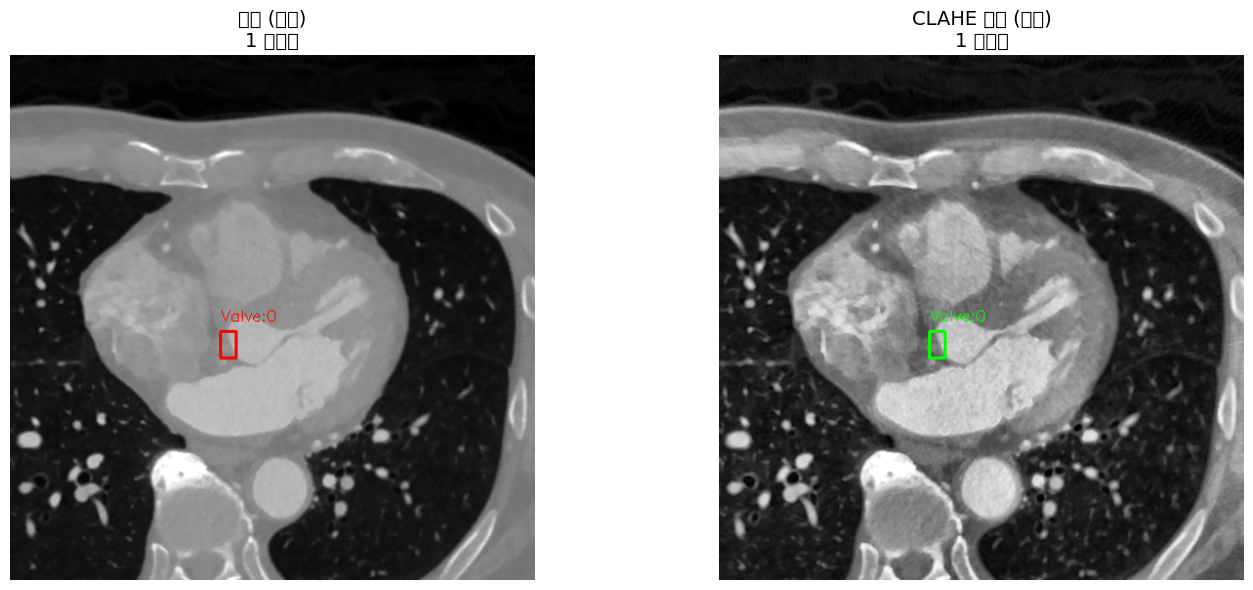

對比度改善: 66.1 → 66.4 (+0.4%)

📊 對比 #2


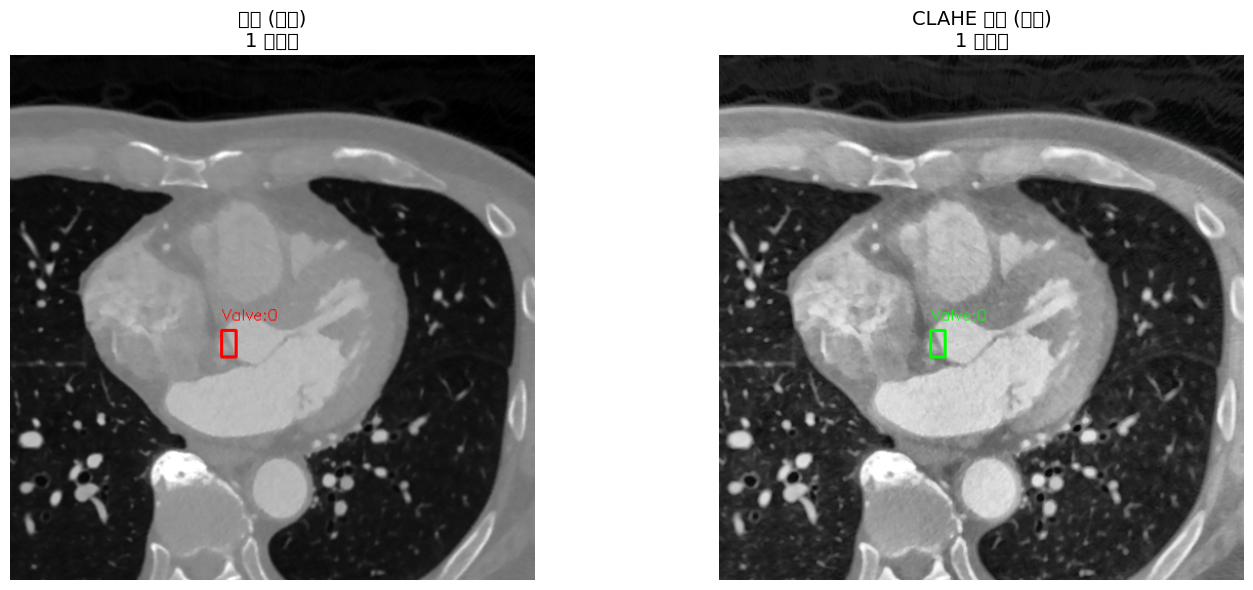

對比度改善: 65.9 → 66.5 (+0.9%)

📊 對比 #3


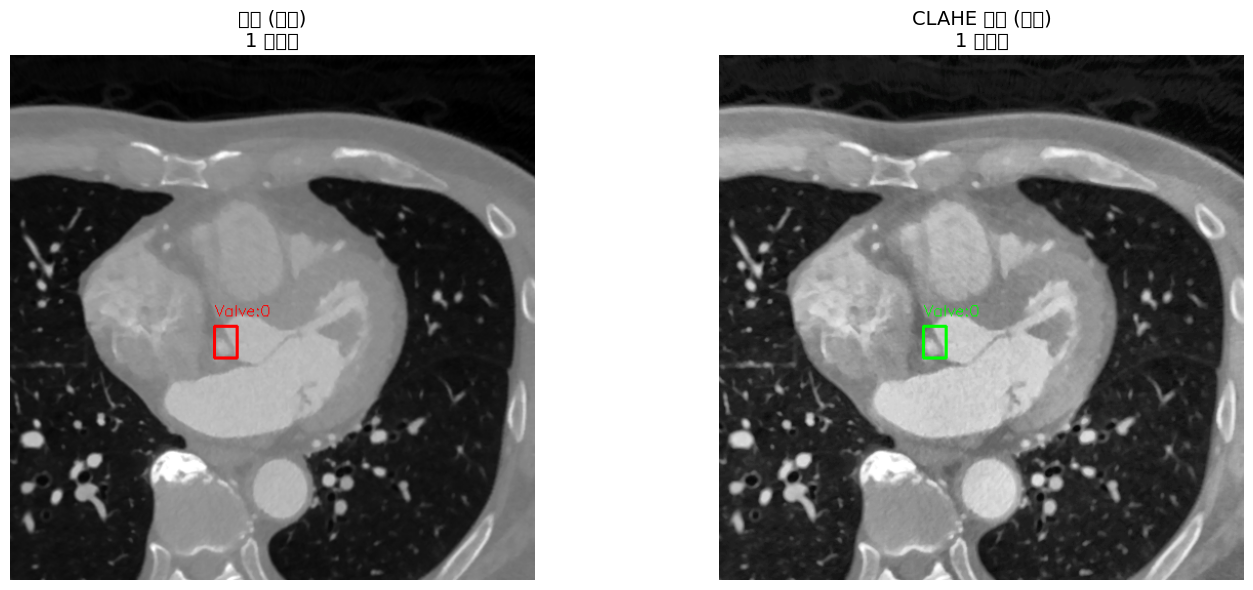

對比度改善: 65.8 → 66.8 (+1.6%)

📊 對比 #4


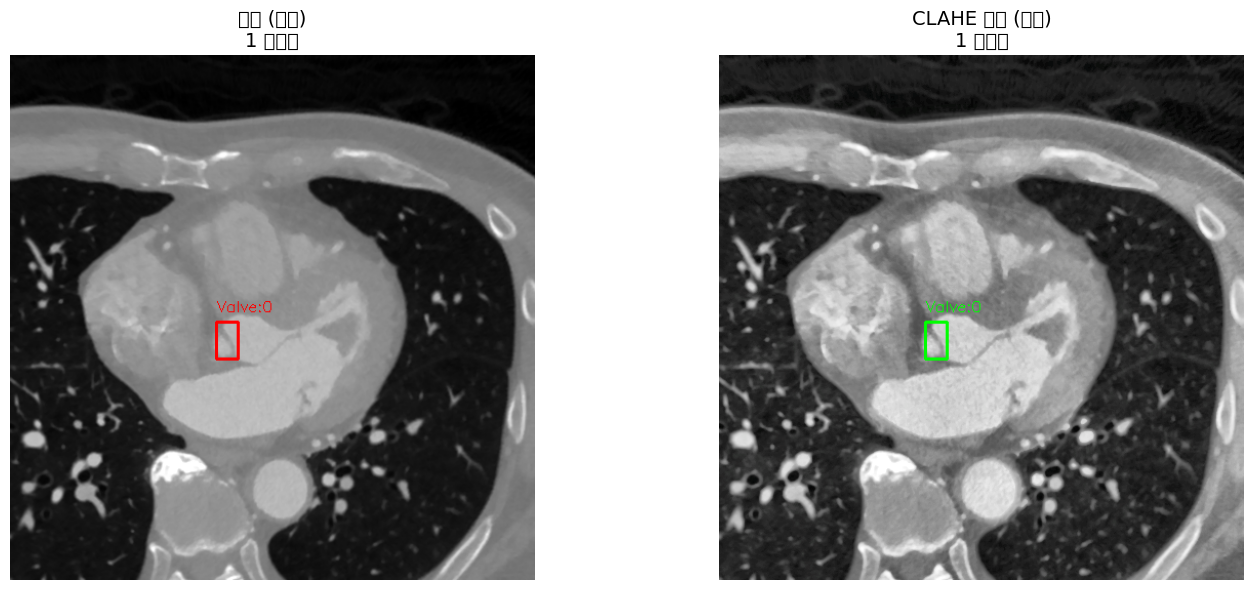

對比度改善: 65.7 → 66.4 (+1.0%)

📊 對比 #5


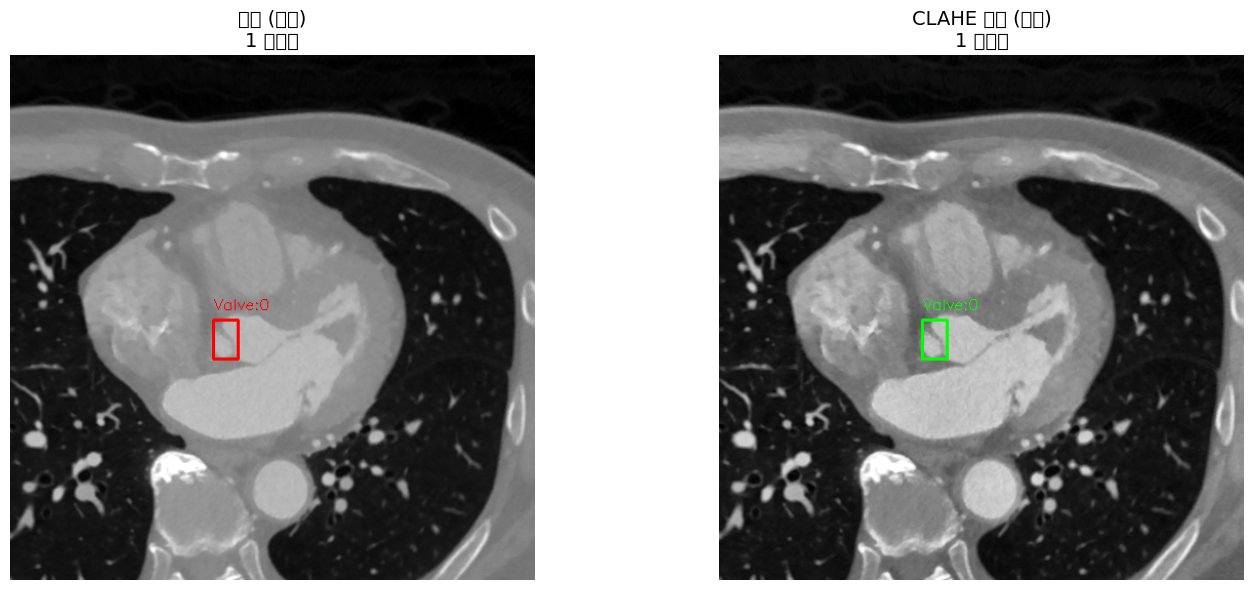

對比度改善: 65.7 → 65.8 (+0.0%)

📊 對比 #6


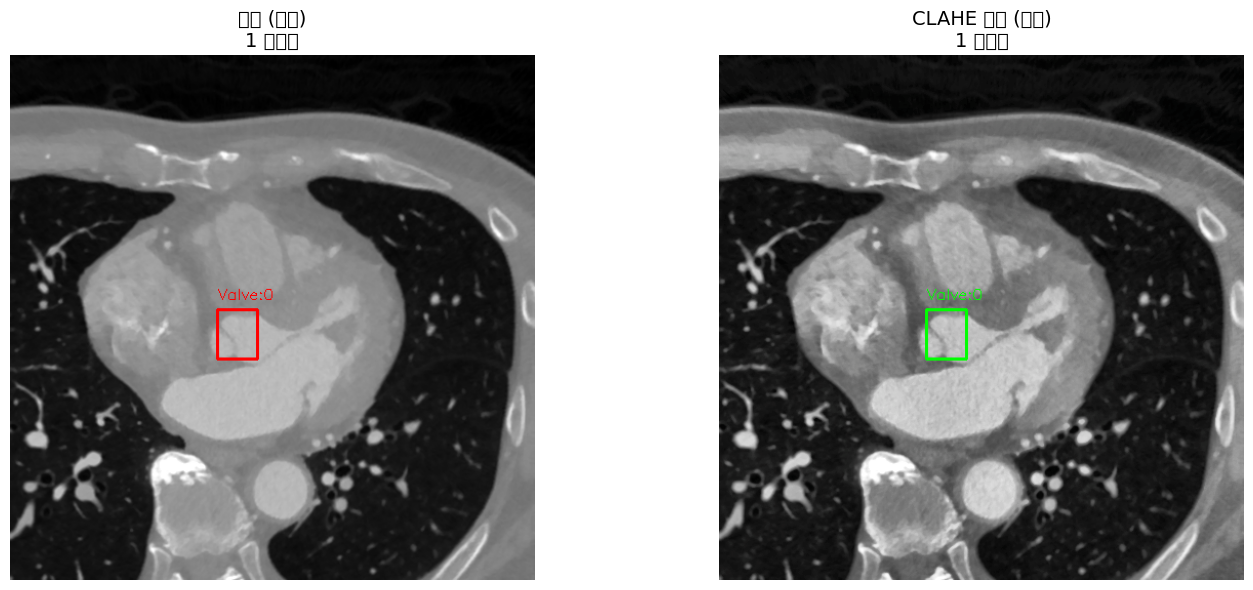

對比度改善: 65.8 → 66.0 (+0.2%)

📈 總結統計：
總瓣環數量：原圖 50 → CLAHE 50
bbox 保留率：100.0%
✅ 檢查完成！CLAHE 效果明顯嗎？


In [6]:
# 主動脈瓣 CT CLAHE 前後對比 Jupyter Notebook
# 在原 Jupyter 第 5 格後面加這段

## 6. 原圖 vs 增強圖 並排對比（含 bbox）
def compare_original_augmented(original_img_path, aug_img_path, original_lbl_path, aug_lbl_path):
    """原圖 vs CLAHE 增強圖並排對比"""

    # 讀取圖片
    orig_img = cv2.imread(original_img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    aug_img = cv2.imread(aug_img_path)
    aug_img = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)

    # 讀取 bbox
    orig_boxes = read_yolo_labels(original_lbl_path)
    aug_boxes = read_yolo_labels(aug_lbl_path)

    # 畫原圖 bbox（紅色）
    for cls, x, y, w, h in orig_boxes:
        x1, y1 = int((x-w/2)*orig_img.shape[1]), int((y-h/2)*orig_img.shape[0])
        x2, y2 = int((x+w/2)*orig_img.shape[1]), int((y+h/2)*orig_img.shape[0])
        cv2.rectangle(orig_img, (x1,y1), (x2,y2), (255,0,0), 2)
        cv2.putText(orig_img, f"Valve:{cls}", (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

    # 畫增強圖 bbox（綠色）
    for cls, x, y, w, h in aug_boxes:
        x1, y1 = int((x-w/2)*aug_img.shape[1]), int((y-h/2)*aug_img.shape[0])
        x2, y2 = int((x+w/2)*aug_img.shape[1]), int((y+h/2)*aug_img.shape[0])
        cv2.rectangle(aug_img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(aug_img, f"Valve:{cls}", (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # 並排顯示
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].imshow(orig_img)
    axes[0].set_title(f'原圖 (紅框)\n{len(orig_boxes)} 個瓣環', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(aug_img)
    axes[1].set_title(f'CLAHE 增強 (綠框)\n{len(aug_boxes)} 個瓣環', fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # 計算對比度改善（簡單標準差）
    orig_std = np.std(orig_img)
    aug_std = np.std(aug_img)
    print(f"對比度改善: {orig_std:.1f} → {aug_std:.1f} ({((aug_std-orig_std)/orig_std*100):+.1f}%)")

## 7. 批次對比檢查（前 6 張模糊瓣環效果）
print("🔍 檢查 CLAHE 前後對比效果...")

# 找 CLAHE 增強的圖片對
clahe_pairs = []
for orig_path in image_paths[:50]:  # 只檢查前 50 張
    name_no_ext = os.path.splitext(os.path.basename(orig_path))[0]
    clahe_img_path = os.path.join(out_img_dir, f"{name_no_ext}_clahe.png")
    clahe_lbl_path = os.path.join(out_lbl_dir, f"{name_no_ext}_clahe.txt")

    if os.path.exists(clahe_img_path):
        orig_lbl = os.path.join(lbl_dir, os.path.splitext(os.path.basename(orig_path))[0] + ".txt")
        clahe_pairs.append((orig_path, clahe_img_path, orig_lbl, clahe_lbl_path))

# 顯示前 6 組對比
for i, (orig_img, clahe_img, orig_lbl, clahe_lbl) in enumerate(clahe_pairs[:6]):
    print(f"\n📊 對比 #{i+1}")
    compare_original_augmented(orig_img, clahe_img, orig_lbl, clahe_lbl)

## 8. 統計總效果
print("\n📈 總結統計：")
orig_total_boxes = 0
clahe_total_boxes = 0

for orig_path, clahe_img, orig_lbl, clahe_lbl in clahe_pairs:
    orig_total_boxes += len(read_yolo_labels(orig_lbl))
    clahe_total_boxes += len(read_yolo_labels(clahe_lbl))

print(f"總瓣環數量：原圖 {orig_total_boxes} → CLAHE {clahe_total_boxes}")
print(f"bbox 保留率：{clahe_total_boxes/orig_total_boxes*100:.1f}%")
print(f"✅ 檢查完成！CLAHE 效果明顯嗎？")

In [4]:
import os
print('訓練集圖片數量 : ',len(os.listdir("./dataset/train/images")))
print('訓練集標記數量 : ',len(os.listdir("./dataset/train/labels")))
print('驗證集圖片數量 : ',len(os.listdir("./dataset/val/images")))
print('驗證集標記數量 : ',len(os.listdir("./dataset/val/labels")))
print('測試集圖片數量 : ',len(os.listdir("./dataset/test/images")))
print('測試集標記數量 : ',len(os.listdir("./dataset/test/labels")))

訓練集圖片數量 :  40066
訓練集標記數量 :  40066
驗證集圖片數量 :  6811
驗證集標記數量 :  6811
測試集圖片數量 :  4352
測試集標記數量 :  4352


In [ ]:
from ultralytics import YOLO
#模型參數參考網址:https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml
model = YOLO('yolo12n.pt') #初次訓練使用YOLO官方的預訓練模型，如要使用自己的模型訓練可以將'yolo12n.pt'替換掉
results = model.train(data="../aortic_valve_colab.yaml",
            epochs=100, #跑幾個epoch
            batch=16, #batch_size
            optimizer = "SGD",
            imgsz=640, #圖片大小640*640
            device=0 #使用GPU進行訓練
            )

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.63  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo12n.pt, data=../aortic_valve_colab.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, 

train: Scanning C:\Users\User\Desktop\ECANet\yolov12\dataset\train\labels... 40066 images, 33965 backgrounds, 0 corrupt


train: New cache created: C:\Users\User\Desktop\ECANet\yolov12\dataset\train\labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


C:\Users\User\Desktop\ECANet\yolov12\ultralytics\data\augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning C:\Users\User\Desktop\ECANet\yolov12\dataset\val\labels... 6811 images, 5926 backgrounds, 0 corrupt: 100%


val: New cache created: C:\Users\User\Desktop\ECANet\yolov12\dataset\val\labels.cache
Plotting labels to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 121 weight(decay=0.0), 136 weight(decay=0.0005), 127 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      6/100       3.5G     0.5748     0.8305     0.2967          0        640: 100%|██████████| 2505/2505 [10:06<00:00,
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 213/213 [00:

                   all       6811        885          0          0          0          0



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      7/100      3.43G     0.5585     0.7826     0.2655          0        640:  79%|███████▉  | 1983/2505 [07:37<01:52,

In [7]:
from ultralytics import YOLO
#模型參數參考網址:https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml
model = YOLO('yolo12n.pt') #初次訓練使用YOLO官方的預訓練模型，如要使用自己的模型訓練可以將'yolo12n.pt'替換掉
results = model.train(data="../aortic_valve_colab.yaml",
            epochs=100, #跑幾個epoch
            batch=16, #batch_size
            optimizer = "SGD",
            imgsz=640, #圖片大小640*640
            device=0 #使用GPU進行訓練
            )

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.63  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo12n.pt, data=../aortic_valve_colab.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train13, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False

train: Scanning C:\Users\User\Desktop\ECANet\datasets\train\labels... 2168 images, 0 backgrounds, 0 corrupt: 100%|█████


train: New cache created: C:\Users\User\Desktop\ECANet\datasets\train\labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


C:\Users\User\Desktop\ECANet\yolov12\ultralytics\data\augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning C:\Users\User\Desktop\ECANet\datasets\val\labels.cache... 619 images, 0 backgrounds, 0 corrupt: 100%|████


Plotting labels to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train13\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 121 weight(decay=0.0), 136 weight(decay=0.0005), 127 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train13
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      3.46G     0.7227     0.3476     0.8898          8        640: 100%|██████████| 136/136 [00:44<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:05

                   all        619        619        0.9      0.926      0.941      0.653



100 epochs completed in 1.471 hours.
Optimizer stripped from C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train13\weights\last.pt, 5.5MB
Optimizer stripped from C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train13\weights\best.pt, 5.5MB

Validating C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train13\weights\best.pt...
Ultralytics 8.3.63  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLOv12n summary (fused): 400 layers, 2,539,275 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:06


                   all        619        619      0.911      0.939      0.957      0.665
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train13


In [9]:
from ultralytics import YOLO
#模型參數參考網址:https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml
model = YOLO('yolo12n.pt') #初次訓練使用YOLO官方的預訓練模型，如要使用自己的模型訓練可以將'yolo12n.pt'替換掉
results = model.train(data="../aortic_valve_colab.yaml",
            epochs=100, #跑幾個epoch
            batch=16, #batch_size
            optimizer = "SGD",
            imgsz=640, #圖片大小640*640
            device=0 #使用GPU進行訓練
            )

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.63  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolo12n.pt, data=../aortic_valve_colab.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train14, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False

train: Scanning C:\Users\User\Desktop\ECANet\datasets\train\labels... 13008 images, 0 backgrounds, 0 corrupt: 100%|████


train: New cache created: C:\Users\User\Desktop\ECANet\datasets\train\labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


C:\Users\User\Desktop\ECANet\yolov12\ultralytics\data\augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning C:\Users\User\Desktop\ECANet\datasets\val\labels.cache... 619 images, 0 backgrounds, 0 corrupt: 100%|████


Plotting labels to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train14\labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 121 weight(decay=0.0), 136 weight(decay=0.0005), 127 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train14
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100       3.5G     0.6037     0.2723     0.8448         16        640: 100%|██████████| 813/813 [04:39<00:00,  
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:06

                   all        619        619      0.888      0.937      0.923      0.638



100 epochs completed in 8.173 hours.
Optimizer stripped from C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train14\weights\last.pt, 5.5MB
Optimizer stripped from C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train14\weights\best.pt, 5.5MB

Validating C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train14\weights\best.pt...
Ultralytics 8.3.63  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
YOLOv12n summary (fused): 400 layers, 2,539,275 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:06


                   all        619        619      0.911       0.96      0.957      0.677
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\User\Desktop\ECANet\yolov12\runs\detect\train14
